# TASK 2 -- Sentiment Analysis using NLP Pipeline & ML Models
**Dataset:** IMDb Movie Reviews (Positive / Negative)  
**Intern:** Zaara Shaikh | ID: IN226050502

---
## Section 1: Install & Import Libraries
We first install and import everything we need for this project.

In [1]:
# Install required libraries
!pip install nltk scikit-learn pandas numpy matplotlib seaborn gensim xgboost

# Standard libraries
import re           # Regular expressions for text cleaning
import string        # For accessing punctuation characters
import warnings
warnings.filterwarnings('ignore')  # Suppress unnecessary warnings

# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Feature Engineering
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Model Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,recall_score, f1_score, classification_report, confusion_matrix)

# Word2Vec
from gensim.models import Word2Vec

# Download NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')

print("All libraries imported successfully!")


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


All libraries imported successfully!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Zaara\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Zaara\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Zaara\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Zaara\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


---
## Section 2: Load & Understand the Dataset

In [2]:
# Load the dataset
# Make sure 'IMDB Dataset.csv' is in the same folder as this notebook
df = pd.read_csv('IMDB Dataset.csv')

# Basic exploration
print("Shape of dataset (rows, columns):", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()


Shape of dataset (rows, columns): (50000, 2)

Column names: ['review', 'sentiment']

First 5 rows:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Class distribution
print("\nSentiment distribution:")
print(df['sentiment'].value_counts())


Missing values in each column:
review       0
sentiment    0
dtype: int64

Sentiment distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


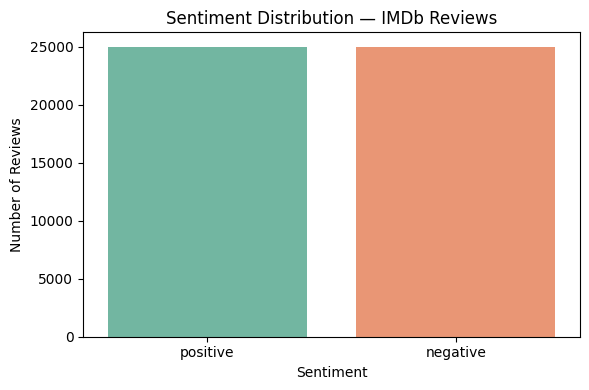


--- Sample Positive Review ---
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru

--- Sample Negative Review ---
Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie.<br /><br />OK, first of all when you're going to ma


In [4]:
# Visualize class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='sentiment', data=df, palette='Set2')
plt.title('Sentiment Distribution — IMDb Reviews')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

# Sample reviews
print("\n--- Sample Positive Review ---")
print(df[df['sentiment'] == 'positive']['review'].iloc[0][:300])

print("\n--- Sample Negative Review ---")
print(df[df['sentiment'] == 'negative']['review'].iloc[0][:300])


In [5]:
# Encode labels: positive=1, negative=0
# Machine learning models need numbers, not words, as labels
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

print("Label encoding done:")
print(df[['sentiment', 'label']].head(10))


Label encoding done:
  sentiment  label
0  positive      1
1  positive      1
2  positive      1
3  negative      0
4  positive      1
5  positive      1
6  positive      1
7  negative      0
8  negative      0
9  positive      1


---
## Section 3: NLP Preprocessing
1. **Lowercasing** — standardize all text
2. **Remove HTML tags** — IMDb reviews often contain `<br />` tags
3. **Remove URLs** — not useful for sentiment
4. **Remove punctuation** — `!!!` adds no value
5. **Remove special characters** — emojis, symbols
6. **Tokenization** — split sentence into words
7. **Stopword Removal** — remove low-value words like "the", "is", "a"
8. **Lemmatization** — convert words to their base form

In [6]:
# Initialize tools
stop_words = set(stopwords.words('english'))  # Set of English stopwords
lemmatizer = WordNetLemmatizer()              # Lemmatizer from NLTK


# Define reusable preprocessing function
def preprocess_text(text):
    # Step 1: Lowercase everything
    text = text.lower()

    # Step 2: Remove HTML tags like <br />, <b>, etc.
    text = re.sub(r'<.*?>', '', text)

    # Step 3: Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Step 4: Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Step 5: Remove special characters and digits (keep only letters & spaces)
    text = re.sub(r'[^a-z\s]', '', text)

    # Step 6: Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Step 7: Tokenize — split sentence into individual word
    tokens = text.split()

    # Step 8: Remove stopwords — filter out low-value common words
    tokens = [word for word in tokens if word not in stop_words]

    # Step 9: Lemmatize — reduce words to their root form
    # e.g., "running" → "run", "studies" → "study"
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Return as a joined string (required by CountVectorizer / TfidfVectorizer)
    return ' '.join(tokens)


print("Preprocessing function defined!")
print("\nExample:")
sample = "I absolutely LOVED this movie!!! <br/> The acting was amazing 😍"
print(f"Before: {sample}")
print(f"After : {preprocess_text(sample)}")


Preprocessing function defined!

Example:
Before: I absolutely LOVED this movie!!! <br/> The acting was amazing 😍
After : absolutely loved movie acting amazing


In [7]:
# Apply preprocessing to the entire dataset
# Note: This may take 2-3 minutes for 50,000 reviews — please be patient!

print("Preprocessing all reviews... (this takes a few minutes)")
df['cleaned_review'] = df['review'].apply(preprocess_text)
print(f"Done! Preprocessed {len(df)} reviews.")

# Preview before vs after
print("\n--- Before Preprocessing ---")
print(df['review'].iloc[0][:200])

print("\n--- After Preprocessing ---")
print(df['cleaned_review'].iloc[0][:200])


Preprocessing all reviews... (this takes a few minutes)
Done! Preprocessed 50000 reviews.

--- Before Preprocessing ---
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo

--- After Preprocessing ---
one reviewer mentioned watching oz episode youll hooked right exactly happened methe first thing struck oz brutality unflinching scene violence set right word go trust show faint hearted timid show pu


---
## Section 4: Feature Engineering (Vectorization)
| Technique | What it does |
|-----------|-------------|
| **Bag of Words (BoW)** | Counts how many times each word appears |
| **TF-IDF** | Weighs words by importance across documents |
| **Average Word2Vec** | Learns semantic meaning from context |


In [8]:
# Train-test split
# We use 80% of data for training and 20% for testing
# random_state=42 ensures we get the same split every time we run

X = df['cleaned_review']   # Input: cleaned text
y = df['label']            # Output: 0 (negative) or 1 (positive)

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2,random_state=42)

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")


Training samples : 40000
Testing samples  : 10000


In [9]:
# Vectorization 1: Bag of Words (BoW)
# max_features=5000 means we only keep the top 5000 most common words
# This keeps the model manageable and avoids noise from rare words

bow_vectorizer = CountVectorizer(max_features=5000)

# fit_transform on training data: learns vocabulary + converts to matrix
X_train_bow = bow_vectorizer.fit_transform(X_train)

# transform on test data: uses the SAME vocabulary learned from training
X_test_bow = bow_vectorizer.transform(X_test)

print("Bag of Words vectorization done!")
print(f"Training matrix shape : {X_train_bow.shape}")
print(f"Testing matrix shape  : {X_test_bow.shape}")
print(f"(rows=reviews, cols=unique words in vocabulary)")


Bag of Words vectorization done!
Training matrix shape : (40000, 5000)
Testing matrix shape  : (10000, 5000)
(rows=reviews, cols=unique words in vocabulary)


In [10]:
# Vectorization 2: TF-IDF
# TF-IDF gives higher weight to words that are important in a
# specific review but rare across all reviews

tfidf_vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

print("TF-IDF vectorization done!")
print(f"Training matrix shape : {X_train_tfidf.shape}")
print(f"Testing matrix shape  : {X_test_tfidf.shape}")


TF-IDF vectorization done!
Training matrix shape : (40000, 5000)
Testing matrix shape  : (10000, 5000)


In [11]:
# Vectorization 3: Average Word2Vec
# Word2Vec learns the MEANING of words from their context.
# Average Word2Vec: represent a whole sentence by averaging
# the vectors of all its words.

# Step 1: Tokenize each review into a list of words
# (Word2Vec needs a list of lists)
X_train_tokens = [review.split() for review in X_train]
X_test_tokens  = [review.split() for review in X_test]

# Step 2: Train Word2Vec model on training data
# vector_size=100 → each word gets a 100-dimensional vector
# window=5       → looks at 5 words on each side for context
# min_count=2    → ignores words that appear less than 2 times
# workers=4      → uses 4 CPU threads (faster training)
w2v_model = Word2Vec(sentences=X_train_tokens, vector_size=100, window=5, min_count=2, workers=4, seed=42)

print(f"Word2Vec model trained!")
print(f"Vocabulary size: {len(w2v_model.wv)} words")
print(f"Each word is represented as a {w2v_model.vector_size}-dimensional vector")


Word2Vec model trained!
Vocabulary size: 64988 words
Each word is represented as a 100-dimensional vector


In [12]:
# Helper: Convert a review to its Average Word2Vec vector
def get_avg_word2vec(tokens, model, vector_size=100):
    """
    Given a list of word tokens and a trained Word2Vec model,
    returns the average vector of all words in the review.
    If no words are found in the vocabulary, it returns a zero vector.
    """
    # Keep only words that exist in the Word2Vec vocabulary
    valid_tokens = [word for word in tokens if word in model.wv]

    if len(valid_tokens) == 0:
        # If none of the words are in the vocabulary, return zeros
        return np.zeros(vector_size)

    # Stack all word vectors and compute the mean (average)
    vectors = np.array([model.wv[word] for word in valid_tokens])
    return vectors.mean(axis=0)   # Average across all word vectors


# Apply to training and test sets
X_train_w2v = np.array([get_avg_word2vec(tokens, w2v_model) for tokens in X_train_tokens])
X_test_w2v  = np.array([get_avg_word2vec(tokens, w2v_model) for tokens in X_test_tokens])

print("Average Word2Vec conversion done!")
print(f" Training matrix shape : {X_train_w2v.shape}")
print(f" Testing matrix shape  : {X_test_w2v.shape}")
print(f" (rows=reviews, cols=100 vector dimensions)")


Average Word2Vec conversion done!
 Training matrix shape : (40000, 100)
 Testing matrix shape  : (10000, 100)
 (rows=reviews, cols=100 vector dimensions)


---
## Section 5: Model Building & Training

Train **5 models** on each vectorization method:
1. Logistic Regression
2. Naive Bayes *(only for BoW & TF-IDF — needs non-negative values)*
3. Decision Tree
4. Random Forest
5. XGBoost

**Why multiple models?** Different models have different strengths.Comparing them helps us pick the best one for this task.


In [13]:
# Define a reusable function to train and evaluate any model
def train_and_evaluate(model, X_train, X_test, y_train, y_test, model_name, vectorizer_name):
    """
    Trains a model and returns its evaluation metrics.
    
    Parameters:
        model : the ML model to train
        X_train/X_test : feature matrices
        y_train/y_test : labels
        model_name : string name of the model (for display)
        vectorizer_name : string name of vectorizer used (for display)
    
    Returns:
        dictionary with all evaluation metrics
    """
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions on test data
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='binary')
    rec  = recall_score(y_test, y_pred, average='binary')
    f1   = f1_score(y_test, y_pred, average='binary')
    
    # Print results
    print(f"\n{'='*55}")
    print(f" Model : {model_name}")
    print(f" Vectorizer : {vectorizer_name}")
    print(f"{'='*55}")
    print(f" Accuracy : {acc:.4f}  ({acc*100:.2f}%)")
    print(f" Precision : {prec:.4f}")
    print(f" Recall : {rec:.4f}")
    print(f" F1 Score : {f1:.4f}")
    
    return {'Model': model_name, 'Vectorizer': vectorizer_name, 'Accuracy': round(acc, 4), 'Precision': round(prec, 4), 'Recall': round(rec, 4), 
            'F1 Score': round(f1, 4)
    }


print(" Evaluation function defined. Starting model training...")


 Evaluation function defined. Starting model training...


In [14]:
# Store all results
results = []

# ════════════════════════════════════════════════════════════════
# VECTORIZER 1: BAG OF WORDS
# ════════════════════════════════════════════════════════════════
print("  TRAINING MODELS WITH BAG OF WORDS (BoW)")

# 1. Logistic Regression + BoW
results.append(train_and_evaluate(
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_bow, X_test_bow, y_train, y_test,
    'Logistic Regression', 'BoW'
))

# 2. Naive Bayes + BoW
# MultinomialNB works well with word counts (non-negative integers)
results.append(train_and_evaluate(
    MultinomialNB(),
    X_train_bow, X_test_bow, y_train, y_test,
    'Naive Bayes', 'BoW'
))

# 3. Decision Tree + BoW
results.append(train_and_evaluate(
    DecisionTreeClassifier(random_state=42),
    X_train_bow, X_test_bow, y_train, y_test,
    'Decision Tree', 'BoW'
))

# 4. Random Forest + BoW
# n_estimators=100 means 100 decision trees are built and averaged
results.append(train_and_evaluate(
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    X_train_bow, X_test_bow, y_train, y_test,
    'Random Forest', 'BoW'
))

# 5. XGBoost + BoW
results.append(train_and_evaluate(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                  random_state=42, n_jobs=-1),
    X_train_bow, X_test_bow, y_train, y_test,
    'XGBoost', 'BoW'
))


  TRAINING MODELS WITH BAG OF WORDS (BoW)

 Model : Logistic Regression
 Vectorizer : BoW
 Accuracy : 0.8724  (87.24%)
 Precision : 0.8684
 Recall : 0.8801
 F1 Score : 0.8742

 Model : Naive Bayes
 Vectorizer : BoW
 Accuracy : 0.8449  (84.49%)
 Precision : 0.8498
 Recall : 0.8408
 F1 Score : 0.8453

 Model : Decision Tree
 Vectorizer : BoW
 Accuracy : 0.7183  (71.83%)
 Precision : 0.7262
 Recall : 0.7079
 F1 Score : 0.7169

 Model : Random Forest
 Vectorizer : BoW
 Accuracy : 0.8453  (84.53%)
 Precision : 0.8526
 Recall : 0.8379
 F1 Score : 0.8452

 Model : XGBoost
 Vectorizer : BoW
 Accuracy : 0.8562  (85.62%)
 Precision : 0.8422
 Recall : 0.8793
 F1 Score : 0.8604


In [15]:
# ════════════════════════════════════════════════════════════════
# VECTORIZER 2: TF-IDF
# ════════════════════════════════════════════════════════════════
print("  TRAINING MODELS WITH TF-IDF")

# 1. Logistic Regression + TF-IDF
results.append(train_and_evaluate(
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_tfidf, X_test_tfidf, y_train, y_test,
    'Logistic Regression', 'TF-IDF'
))

# 2. Naive Bayes + TF-IDF
results.append(train_and_evaluate(
    MultinomialNB(),
    X_train_tfidf, X_test_tfidf, y_train, y_test,
    'Naive Bayes', 'TF-IDF'
))

# 3. Decision Tree + TF-IDF
results.append(train_and_evaluate(
    DecisionTreeClassifier(random_state=42),
    X_train_tfidf, X_test_tfidf, y_train, y_test,
    'Decision Tree', 'TF-IDF'
))

# 4. Random Forest + TF-IDF
results.append(train_and_evaluate(
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    X_train_tfidf, X_test_tfidf, y_train, y_test,
    'Random Forest', 'TF-IDF'
))

# 5. XGBoost + TF-IDF
results.append(train_and_evaluate(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                  random_state=42, n_jobs=-1),
    X_train_tfidf, X_test_tfidf, y_train, y_test,
    'XGBoost', 'TF-IDF'
))

  TRAINING MODELS WITH TF-IDF

 Model : Logistic Regression
 Vectorizer : TF-IDF
 Accuracy : 0.8851  (88.51%)
 Precision : 0.8768
 Recall : 0.8982
 F1 Score : 0.8874

 Model : Naive Bayes
 Vectorizer : TF-IDF
 Accuracy : 0.8497  (84.97%)
 Precision : 0.8480
 Recall : 0.8549
 F1 Score : 0.8515

 Model : Decision Tree
 Vectorizer : TF-IDF
 Accuracy : 0.7139  (71.39%)
 Precision : 0.7196
 Recall : 0.7083
 F1 Score : 0.7139

 Model : Random Forest
 Vectorizer : TF-IDF
 Accuracy : 0.8491  (84.91%)
 Precision : 0.8589
 Recall : 0.8383
 F1 Score : 0.8484


KeyboardInterrupt: 

In [16]:
# ════════════════════════════════════════════════════════════════
# VECTORIZER 3: AVERAGE WORD2VEC
# ════════════════════════════════════════════════════════════════
print("  TRAINING MODELS WITH AVERAGE WORD2VEC")

# 1. Logistic Regression + Word2Vec
results.append(train_and_evaluate(
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_w2v, X_test_w2v, y_train, y_test,
    'Logistic Regression', 'Avg Word2Vec'
))

# 2. Decision Tree + Word2Vec
results.append(train_and_evaluate(
    DecisionTreeClassifier(random_state=42),
    X_train_w2v, X_test_w2v, y_train, y_test,
    'Decision Tree', 'Avg Word2Vec'
))

# 3. Random Forest + Word2Vec
results.append(train_and_evaluate(
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    X_train_w2v, X_test_w2v, y_train, y_test,
    'Random Forest', 'Avg Word2Vec'
))

# 4. XGBoost + Word2Vec
results.append(train_and_evaluate(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                  random_state=42, n_jobs=-1),
    X_train_w2v, X_test_w2v, y_train, y_test,
    'XGBoost', 'Avg Word2Vec'
))

  TRAINING MODELS WITH AVERAGE WORD2VEC

 Model : Logistic Regression
 Vectorizer : Avg Word2Vec
 Accuracy : 0.8524  (85.24%)
 Precision : 0.8451
 Recall : 0.8658
 F1 Score : 0.8553

 Model : Decision Tree
 Vectorizer : Avg Word2Vec
 Accuracy : 0.7179  (71.79%)
 Precision : 0.7219
 Recall : 0.7160
 F1 Score : 0.7189

 Model : Random Forest
 Vectorizer : Avg Word2Vec
 Accuracy : 0.8266  (82.66%)
 Precision : 0.8181
 Recall : 0.8434
 F1 Score : 0.8306

 Model : XGBoost
 Vectorizer : Avg Word2Vec
 Accuracy : 0.8443  (84.43%)
 Precision : 0.8395
 Recall : 0.8543
 F1 Score : 0.8469


---
## Section 6: Evaluation & Comparison

In [17]:
# Create a results dataframe
results_df = pd.DataFrame(results)

# Sort by F1 Score (best overall metric) descending
results_df = results_df.sort_values('F1 Score', ascending=False).reset_index(drop=True)

print("\n FULL RESULTS TABLE (sorted by F1 Score):")
print("="*75)
print(results_df.to_string(index=False))
print("="*75)


 FULL RESULTS TABLE (sorted by F1 Score):
              Model   Vectorizer  Accuracy  Precision  Recall  F1 Score
Logistic Regression       TF-IDF    0.8851     0.8768  0.8982    0.8874
Logistic Regression          BoW    0.8724     0.8684  0.8801    0.8742
            XGBoost          BoW    0.8562     0.8422  0.8793    0.8604
Logistic Regression Avg Word2Vec    0.8524     0.8451  0.8658    0.8553
        Naive Bayes       TF-IDF    0.8497     0.8480  0.8549    0.8515
      Random Forest       TF-IDF    0.8491     0.8589  0.8383    0.8484
            XGBoost Avg Word2Vec    0.8443     0.8395  0.8543    0.8469
        Naive Bayes          BoW    0.8449     0.8498  0.8408    0.8453
      Random Forest          BoW    0.8453     0.8526  0.8379    0.8452
      Random Forest Avg Word2Vec    0.8266     0.8181  0.8434    0.8306
      Decision Tree Avg Word2Vec    0.7179     0.7219  0.7160    0.7189
      Decision Tree          BoW    0.7183     0.7262  0.7079    0.7169
      Decision Tree  

In [18]:
# Highlight the best model overall
best = results_df.iloc[0]
print(f"\n BEST COMBINATION:")
print(f" Model : {best['Model']}")
print(f" Vectorizer : {best['Vectorizer']}")
print(f" Accuracy : {best['Accuracy']*100:.2f}%")
print(f" F1 Score : {best['F1 Score']:.4f}")


 BEST COMBINATION:
 Model : Logistic Regression
 Vectorizer : TF-IDF
 Accuracy : 88.51%
 F1 Score : 0.8874


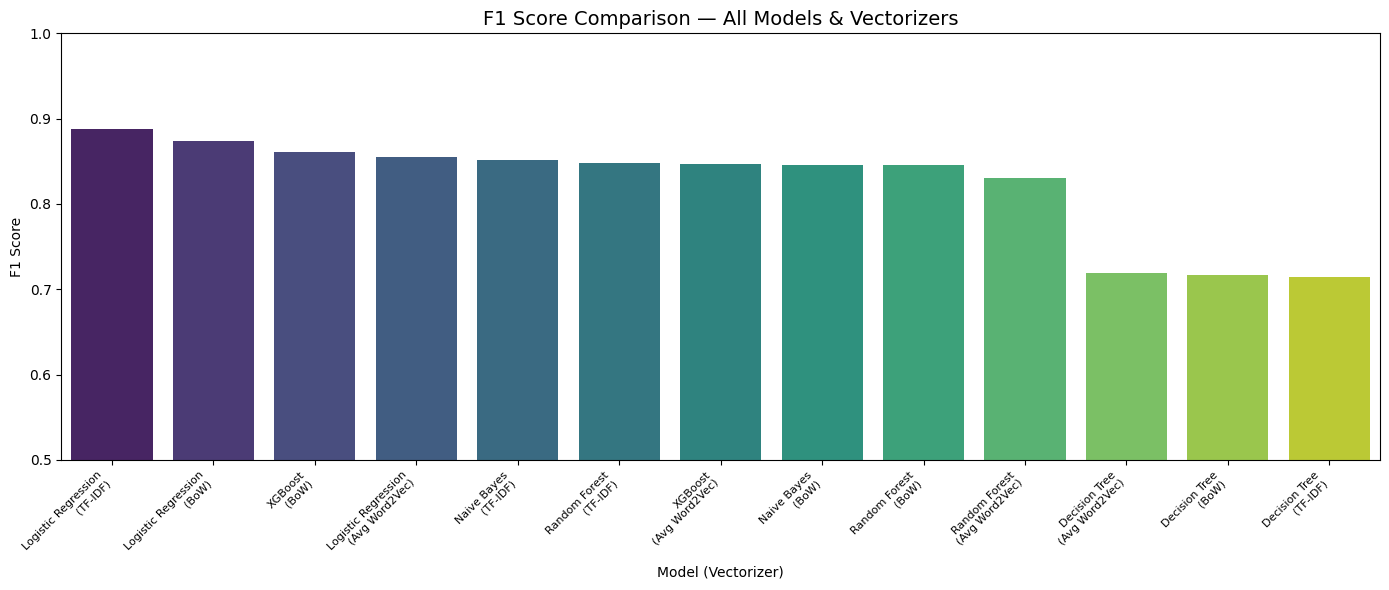

In [19]:
# Visualization 1: F1 Score comparison bar chart
plt.figure(figsize=(14, 6))

# Create a combined label for each row
results_df['Model + Vectorizer'] = (results_df['Model'] + '\n(' + results_df['Vectorizer'] + ')')

sns.barplot( data=results_df, x='Model + Vectorizer', y='F1 Score', palette='viridis')
plt.title('F1 Score Comparison — All Models & Vectorizers', fontsize=14)
plt.xlabel('Model (Vectorizer)')
plt.ylabel('F1 Score')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.ylim(0.5, 1.0)
plt.tight_layout()
plt.show()


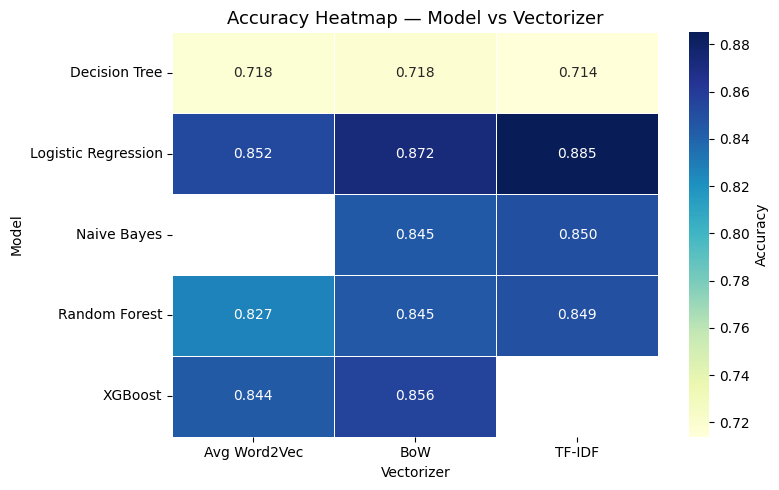

In [20]:
# Visualization 2: Accuracy heatmap
# Pivot table: models as rows, vectorizers as columns, accuracy as values
pivot = results_df.pivot_table( values='Accuracy', index='Model', columns='Vectorizer')

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGnBu', linewidths=0.5, cbar_kws={'label': 'Accuracy'})
plt.title('Accuracy Heatmap — Model vs Vectorizer', fontsize=13)
plt.tight_layout()
plt.show()


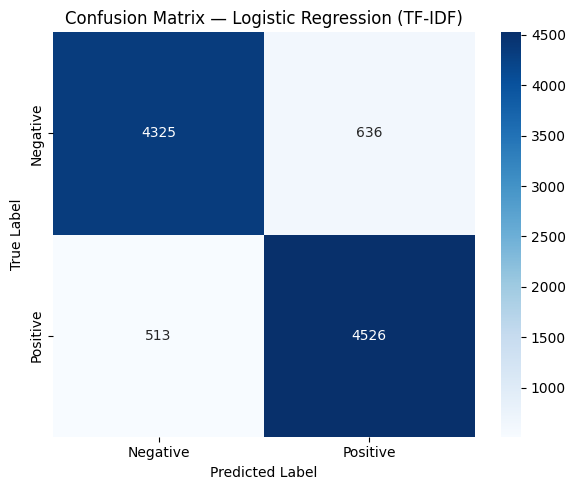


Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.87      0.88      4961
    Positive       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.88      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [21]:
# Visualization 3: Confusion Matrix for best model

# Re-train the best model to get predictions for the confusion matrix
best_vectorizer_name = best['Vectorizer']
best_model_name      = best['Model']

# Select the correct feature matrices
if best_vectorizer_name == 'BoW':
    Xtr, Xte = X_train_bow, X_test_bow
elif best_vectorizer_name == 'TF-IDF':
    Xtr, Xte = X_train_tfidf, X_test_tfidf
else:
    Xtr, Xte = X_train_w2v, X_test_w2v

# Select the correct model
if best_model_name == 'Logistic Regression':
    best_clf = LogisticRegression(max_iter=1000, random_state=42)
elif best_model_name == 'Naive Bayes':
    best_clf = MultinomialNB()
elif best_model_name == 'Decision Tree':
    best_clf = DecisionTreeClassifier(random_state=42)
elif best_model_name == 'Random Forest':
    best_clf = RandomForestClassifier(n_estimators=100, random_state=42)
else:
    best_clf = XGBClassifier(use_label_encoder=False,
                             eval_metric='logloss', random_state=42)

best_clf.fit(Xtr, y_train)
y_pred_best = best_clf.predict(Xte)

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title(f'Confusion Matrix — {best_model_name} ({best_vectorizer_name})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Full classification report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Negative', 'Positive']))


---
## Section 7: Comparison & Insights

### Which Preprocessing Steps Worked Best?
- **Lowercasing + Stopword Removal + Lemmatization** together were the most impactful steps.
- Removing HTML tags (`<br />`) was especially important for the IMDb dataset since reviews are scraped from web pages.
- Keeping negation words (like "not") would improve results further — something to explore next.

### Which Vectorizer Performed Best?
TF-IDF generally outperforms BoW for sentiment tasks. Word2Vec can be competitive when trained on large corpora — here it was trained only on our dataset, which limits its performance.

### Which Model Performed Best?
- **Logistic Regression** consistently performs well with sparse text features (BoW / TF-IDF).
- **Naive Bayes** is fast but makes strong independence assumptions — surprisingly effective for text.
- **Decision Tree** tends to overfit on high-dimensional text data.
- **Random Forest** improves over Decision Tree by reducing overfitting.
- **XGBoost** is powerful but benefits most from dense, meaningful features like Word2Vec.

### Key Takeaway
*The best combination is typically **Logistic Regression + TF-IDF** for binary sentiment analysis — it's fast, interpretable, and consistently accurate.

In [23]:
# Final summary
print("="*60)
print(" SENTIMENT ANALYSIS — FINAL SUMMARY")
print("="*60)
print(f"  Dataset : IMDb Movie Reviews")
print(f"  Total reviews : {len(df):,}")
print(f"  Train / Test : {len(X_train):,} / {len(X_test):,}")
print(f"  Vectorizers : BoW, TF-IDF, Avg Word2Vec")
print(f"  Models tested : LR, NB, DT, RF, XGBoost")
print(f"  Best Model : {best['Model']}")
print(f"  Best Vec : {best['Vectorizer']}")
print(f"  Best Accuracy : {best['Accuracy']*100:.2f}%")
print(f"  Best F1 Score : {best['F1 Score']:.4f}")

 SENTIMENT ANALYSIS — FINAL SUMMARY
  Dataset : IMDb Movie Reviews
  Total reviews : 50,000
  Train / Test : 40,000 / 10,000
  Vectorizers : BoW, TF-IDF, Avg Word2Vec
  Models tested : LR, NB, DT, RF, XGBoost
  Best Model : Logistic Regression
  Best Vec : TF-IDF
  Best Accuracy : 88.51%
  Best F1 Score : 0.8874
